# 01 Data Collection

## Objective

Collect public country-level population, urbanization, and macroeconomic data for the Global Housing Affordability Stress Index project.

## Data Source

World Bank World Development Indicators API

## Output Files

- `data/raw/world_bank_indicators_long.csv`
- `data/interim/world_bank_country_year.csv`

In [1]:
import pandas as pd
import requests
from pathlib import Path

RAW_DIR = Path("../data/raw")
INTERIM_DIR = Path("../data/interim")

RAW_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")

Setup complete


In [2]:
indicator_code = "SP.POP.TOTL"

url = (
    f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    f"?format=json&per_page=20000&date=2000:2024"
)

response = requests.get(url)

print("Status code:", response.status_code)
print("Response type:", type(response))

Status code: 200
Response type: <class 'requests.models.Response'>


In [3]:
data = response.json()

# The World Bank API returns metadata in data[0]
# and the actual records in data[1]
records = data[1]

rows = []

for record in records:
    rows.append({
        "country_id": record["countryiso3code"],
        "country_name": record["country"]["value"],
        "year": int(record["date"]),
        "indicator_code": indicator_code,
        "value": record["value"]
    })

population_df = pd.DataFrame(rows)

population_df.head()

,country_id,country_name,year,indicator_code,value
0,AFE,Africa Eastern and Southern,2024,SP.POP.TOTL,769280888.0
1,AFE,Africa Eastern and Southern,2023,SP.POP.TOTL,750491370.0
2,AFE,Africa Eastern and Southern,2022,SP.POP.TOTL,731821393.0
3,AFE,Africa Eastern and Southern,2021,SP.POP.TOTL,713090928.0
4,AFE,Africa Eastern and Southern,2020,SP.POP.TOTL,694446100.0


In [4]:
population_df.shape

(6650, 5)

In [5]:
def fetch_world_bank_indicator(indicator_code, start_year=2000, end_year=2024):
    """
    Fetch one World Bank indicator for all countries.
    Returns a long-format DataFrame.
    """

    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
        f"?format=json&per_page=20000&date={start_year}:{end_year}"
    )

    response = requests.get(url)
    response.raise_for_status()

    data = response.json()

    if len(data) < 2:
        return pd.DataFrame()

    records = data[1]
    rows = []

    for record in records:
        rows.append({
            "country_id": record["countryiso3code"],
            "country_name": record["country"]["value"],
            "year": int(record["date"]),
            "indicator_code": indicator_code,
            "value": record["value"]
        })

    return pd.DataFrame(rows)

In [6]:
test_df = fetch_world_bank_indicator("SP.URB.TOTL.IN.ZS")

test_df.head()

,country_id,country_name,year,indicator_code,value
0,AFE,Africa Eastern and Southern,2024,SP.URB.TOTL.IN.ZS,38.241441
1,AFE,Africa Eastern and Southern,2023,SP.URB.TOTL.IN.ZS,37.772301
2,AFE,Africa Eastern and Southern,2022,SP.URB.TOTL.IN.ZS,37.360578
3,AFE,Africa Eastern and Southern,2021,SP.URB.TOTL.IN.ZS,36.908543
4,AFE,Africa Eastern and Southern,2020,SP.URB.TOTL.IN.ZS,36.488322


In [7]:
WORLD_BANK_INDICATORS = {
    "SP.POP.TOTL": "population_total",
    "SP.URB.TOTL.IN.ZS": "urban_population_pct",
    "SP.URB.GROW": "urban_population_growth_pct",
    "NY.GDP.PCAP.CD": "gdp_per_capita_current_usd",
    "NY.GDP.PCAP.KD": "gdp_per_capita_constant_usd",
    "FP.CPI.TOTL.ZG": "inflation_pct",
    "SL.UEM.TOTL.ZS": "unemployment_pct"
}

WORLD_BANK_INDICATORS

{'SP.POP.TOTL': 'population_total',
 'SP.URB.TOTL.IN.ZS': 'urban_population_pct',
 'SP.URB.GROW': 'urban_population_growth_pct',
 'NY.GDP.PCAP.CD': 'gdp_per_capita_current_usd',
 'NY.GDP.PCAP.KD': 'gdp_per_capita_constant_usd',
 'FP.CPI.TOTL.ZG': 'inflation_pct',
 'SL.UEM.TOTL.ZS': 'unemployment_pct'}

In [8]:
all_indicator_frames = []

for code, name in WORLD_BANK_INDICATORS.items():
    print(f"Fetching {code}: {name}")

    df = fetch_world_bank_indicator(code)
    df["indicator_name"] = name

    all_indicator_frames.append(df)

world_bank_long = pd.concat(all_indicator_frames, ignore_index=True)

print("Rows collected:", len(world_bank_long))
world_bank_long.head()

Fetching SP.POP.TOTL: population_total
Fetching SP.URB.TOTL.IN.ZS: urban_population_pct
Fetching SP.URB.GROW: urban_population_growth_pct
Fetching NY.GDP.PCAP.CD: gdp_per_capita_current_usd
Fetching NY.GDP.PCAP.KD: gdp_per_capita_constant_usd
Fetching FP.CPI.TOTL.ZG: inflation_pct
Fetching SL.UEM.TOTL.ZS: unemployment_pct
Rows collected: 46550


,country_id,country_name,year,indicator_code,value,indicator_name
0,AFE,Africa Eastern and Southern,2024,SP.POP.TOTL,769280888.0,population_total
1,AFE,Africa Eastern and Southern,2023,SP.POP.TOTL,750491370.0,population_total
2,AFE,Africa Eastern and Southern,2022,SP.POP.TOTL,731821393.0,population_total
3,AFE,Africa Eastern and Southern,2021,SP.POP.TOTL,713090928.0,population_total
4,AFE,Africa Eastern and Southern,2020,SP.POP.TOTL,694446100.0,population_total


In [9]:
world_bank_long.to_csv(RAW_DIR / "world_bank_indicators_long.csv", index=False)

print("Saved raw World Bank data to:")
print(RAW_DIR / "world_bank_indicators_long.csv")

Saved raw World Bank data to:
..\data\raw\world_bank_indicators_long.csv


In [10]:
world_bank_wide = (
    world_bank_long
    .pivot_table(
        index=["country_id", "country_name", "year"],
        columns="indicator_name",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

world_bank_wide.columns.name = None

world_bank_wide.head()

,country_id,country_name,year,gdp_per_capita_constant_usd,gdp_per_capita_current_usd,inflation_pct,population_total,unemployment_pct,urban_population_growth_pct,urban_population_pct
0,,High income,2000,30158.070078,22374.325475,NaN,1.255696e+09,7.023303,0.801117,76.124359
1,,High income,2001,30481.297187,22083.420167,NaN,1.262094e+09,6.870712,0.848123,76.383580
2,,High income,2002,30822.944048,22929.756695,NaN,1.268560e+09,7.194001,0.931866,76.705729
3,,High income,2003,31366.542132,25606.676644,NaN,1.275201e+09,7.319752,0.983765,77.060638
4,,High income,2004,32292.646997,28451.506548,NaN,1.282168e+09,7.095800,0.996721,77.409597


In [11]:
world_bank_wide.shape

(6625, 10)

In [12]:
world_bank_wide[
    world_bank_wide["country_name"].isin([
        "United States",
        "Canada",
        "Germany",
        "United Kingdom",
        "Australia"
    ])
].head(20)

,country_id,country_name,year,gdp_per_capita_constant_usd,gdp_per_capita_current_usd,inflation_pct,population_total,unemployment_pct,urban_population_growth_pct,urban_population_pct
425,AUS,Australia,2000,45979.076565,21908.996802,4.457437,19028802.0,6.288,1.124074,85.107161
426,AUS,Australia,2001,46314.623530,19733.651010,4.407130,19274701.0,6.747,1.332068,85.148109
427,AUS,Australia,2002,47599.407929,20335.096019,2.981571,19495210.0,6.375,1.297255,85.284210
428,AUS,Australia,2003,48509.663218,23757.589847,2.732598,19720737.0,5.933,1.297237,85.409708
429,AUS,Australia,2004,50018.590448,30886.050095,2.343257,19932722.0,5.399,1.196805,85.518768
430,AUS,Australia,2005,50972.640520,34535.207271,2.691829,20176844.0,5.036,1.334532,85.619087
431,AUS,Australia,2006,51682.892523,36658.824348,3.555287,20450966.0,4.785,1.501365,85.749254
432,AUS,Australia,2007,52671.325847,41128.247662,2.327614,20827622.0,4.381,1.996977,85.896852
433,AUS,Australia,2008,53497.275355,49811.206722,4.350297,21249199.0,4.242,2.153433,86.025382
434,AUS,Australia,2009,53430.527478,42954.849488,1.771120,21691653.0,5.565,2.179834,86.127814


In [13]:
world_bank_wide.to_csv(INTERIM_DIR / "world_bank_country_year.csv", index=False)

print("Saved clean World Bank country-year file to:")
print(INTERIM_DIR / "world_bank_country_year.csv")

Saved clean World Bank country-year file to:
..\data\interim\world_bank_country_year.csv


## Basic Data Quality Checks

Before moving to analysis, I checked the structure, year coverage, country coverage, missing values, and duplicate records in the World Bank dataset.

In [14]:
world_bank_wide.columns

Index(['country_id', 'country_name', 'year', 'gdp_per_capita_constant_usd',
       'gdp_per_capita_current_usd', 'inflation_pct', 'population_total',
       'unemployment_pct', 'urban_population_growth_pct',
       'urban_population_pct'],
      dtype='str')

In [15]:
print("Minimum year:", world_bank_wide["year"].min())
print("Maximum year:", world_bank_wide["year"].max())

Minimum year: 2000
Maximum year: 2024


In [16]:
print("Number of country/entity codes:", world_bank_wide["country_id"].nunique())
print("Number of country/entity names:", world_bank_wide["country_name"].nunique())

Number of country/entity codes: 262
Number of country/entity names: 265


In [17]:
missing_summary = (
    world_bank_wide
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

inflation_pct                  2056
unemployment_pct                759
gdp_per_capita_constant_usd     274
gdp_per_capita_current_usd      192
urban_population_growth_pct       1
country_id                        0
country_name                      0
year                              0
population_total                  0
urban_population_pct              0
dtype: int64

In [18]:
duplicate_count = world_bank_wide.duplicated(
    subset=["country_id", "country_name", "year"]
).sum()

print("Duplicate country-year rows:", duplicate_count)

Duplicate country-year rows: 0


## First Exploratory Chart

To confirm the World Bank data can support trend analysis, I plotted urban population share over time for selected countries.

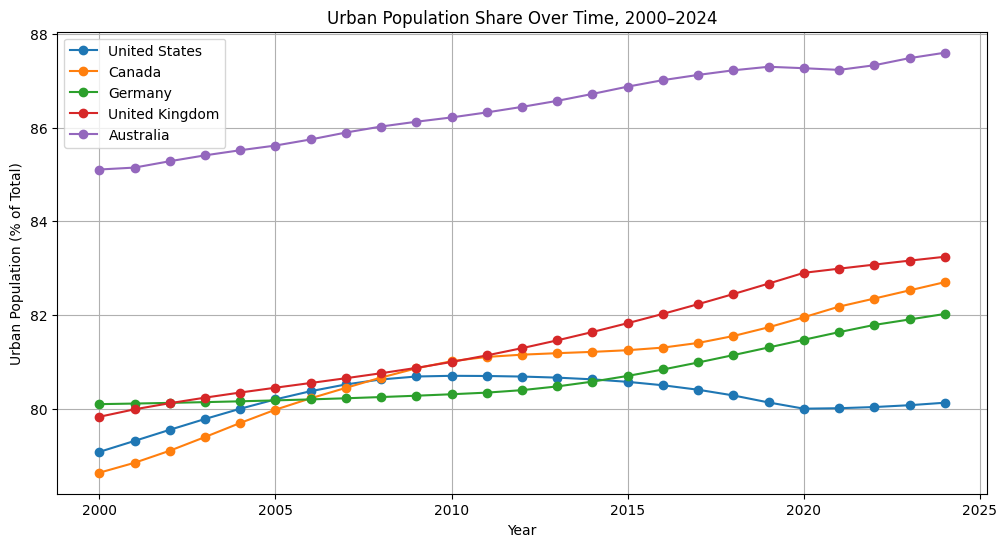

In [19]:
import matplotlib.pyplot as plt

sample_countries = [
    "United States",
    "Canada",
    "Germany",
    "United Kingdom",
    "Australia"
]

plot_df = world_bank_wide[
    world_bank_wide["country_name"].isin(sample_countries)
].copy()

plot_df = plot_df.sort_values(["country_name", "year"])

plt.figure(figsize=(12, 6))

for country in sample_countries:
    country_df = plot_df[plot_df["country_name"] == country]
    plt.plot(
        country_df["year"],
        country_df["urban_population_pct"],
        marker="o",
        label=country
    )

plt.title("Urban Population Share Over Time, 2000–2024")
plt.xlabel("Year")
plt.ylabel("Urban Population (% of Total)")
plt.legend()
plt.grid(True)
plt.show()

## OECD Housing Data Collection

Next, I collected OECD Analytical House Price Indicators. These indicators include nominal house price indices, real house price indices, price-to-income ratios, price-to-rent ratios, and rent price indices.

This dataset will be joined later with World Bank country-year indicators.

In [20]:
from io import StringIO

OECD_HOUSING_URL = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.ECO.MPD%2CDSD_AN_HOUSE_PRICES%40DF_HOUSE_PRICES%2C/"
    "all?"
    "dimensionAtObservation=AllDimensions"
    "&format=csvfilewithlabels"
    "&startPeriod=2000"
    "&endPeriod=2024"
)

response = requests.get(OECD_HOUSING_URL)

print("Status code:", response.status_code)
print("First 500 characters:")
print(response.text[:500])

Status code: 200
First 500 characters:
STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,UNIT_MEASURE,Unit of measure,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,ADJUSTMENT,Adjustment,DECIMALS,Decimals,BASE_PER,Base period
DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRICES(1.0),Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,IX,Index,2000-Q1,,68.1953024048021,,A,Normal val


In [21]:
from io import StringIO

oecd_raw = pd.read_csv(StringIO(response.text))

print("Rows:", len(oecd_raw))
print("Columns:", len(oecd_raw.columns))

oecd_raw.head()

Rows: 33659
Columns: 26


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,ADJUSTMENT,Adjustment,DECIMALS,Decimals,BASE_PER,Base period
0,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
1,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
2,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
3,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
4,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN


In [22]:
oecd_raw.columns.tolist()

['STRUCTURE',
 'STRUCTURE_ID',
 'STRUCTURE_NAME',
 'ACTION',
 'REF_AREA',
 'Reference area',
 'FREQ',
 'Frequency of observation',
 'MEASURE',
 'Measure',
 'UNIT_MEASURE',
 'Unit of measure',
 'TIME_PERIOD',
 'Time period',
 'OBS_VALUE',
 'Observation value',
 'OBS_STATUS',
 'Observation status',
 'UNIT_MULT',
 'Unit multiplier',
 'ADJUSTMENT',
 'Adjustment',
 'DECIMALS',
 'Decimals',
 'BASE_PER',
 'Base period']

In [23]:
oecd_raw.to_csv(RAW_DIR / "oecd_housing_prices_raw.csv", index=False)

print("Saved raw OECD housing data to:")
print(RAW_DIR / "oecd_housing_prices_raw.csv")

Saved raw OECD housing data to:
..\data\raw\oecd_housing_prices_raw.csv


## OECD Data Inspection

Before cleaning the OECD housing dataset, I inspected the available countries, frequencies, measures, time periods, and observation values.

In [24]:
oecd_raw.head(10)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,ADJUSTMENT,Adjustment,DECIMALS,Decimals,BASE_PER,Base period
0,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
1,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
2,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
3,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
4,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
5,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
6,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
7,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
8,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN
9,DATAFLOW,OECD.ECO.MPD:DSD_AN_HOUSE_PRICES@DF_HOUSE_PRIC...,Analytical house prices indicators,I,OECD,OECD,Q,Quarterly,RPI,Rent prices,...,A,Normal value,0,Units,S,"Seasonally adjusted, not calendar adjusted",1,One,2015.0,NaN


In [25]:
for col in oecd_raw.columns:
    print(col)

STRUCTURE
STRUCTURE_ID
STRUCTURE_NAME
ACTION
REF_AREA
Reference area
FREQ
Frequency of observation
MEASURE
Measure
UNIT_MEASURE
Unit of measure
TIME_PERIOD
Time period
OBS_VALUE
Observation value
OBS_STATUS
Observation status
UNIT_MULT
Unit multiplier
ADJUSTMENT
Adjustment
DECIMALS
Decimals
BASE_PER
Base period


In [26]:
measure_cols = [col for col in oecd_raw.columns if "MEASURE" in col.upper() or "Measure" in col]

print("Possible measure columns:")
print(measure_cols)

for col in measure_cols:
    print("\nColumn:", col)
    print(oecd_raw[col].dropna().unique()[:30])

Possible measure columns:
['MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure']

Column: MEASURE
<StringArray>
['RPI', 'HPI_RPI', 'HPI', 'RHP', 'HPI_YDH', 'HPI_YDH_AVG', 'HPI_RPI_AVG']
Length: 7, dtype: str

Column: Measure
<StringArray>
[                    'Rent prices',             'Price to rent ratio',
     'Nominal house price indices',        'Real house price indices',
           'Price to income ratio', 'Standardised price-income ratio',
   'Standardised price-rent ratio']
Length: 7, dtype: str

Column: UNIT_MEASURE
<StringArray>
['IX', 'PT_AVG_L_TERM']
Length: 2, dtype: str

Column: Unit of measure
<StringArray>
['Index', 'Percentage of long term average']
Length: 2, dtype: str


In [27]:
freq_cols = [col for col in oecd_raw.columns if "FREQ" in col.upper() or "Frequency" in col]

print("Possible frequency columns:")
print(freq_cols)

for col in freq_cols:
    print("\nColumn:", col)
    print(oecd_raw[col].dropna().unique()[:20])

Possible frequency columns:
['FREQ', 'Frequency of observation']

Column: FREQ
<StringArray>
['Q', 'A']
Length: 2, dtype: str

Column: Frequency of observation
<StringArray>
['Quarterly', 'Annual']
Length: 2, dtype: str


In [28]:
time_cols = [col for col in oecd_raw.columns if "TIME" in col.upper() or "Time" in col]

print("Possible time columns:")
print(time_cols)

for col in time_cols:
    print("\nColumn:", col)
    print("Min:", oecd_raw[col].min())
    print("Max:", oecd_raw[col].max())

Possible time columns:
['TIME_PERIOD', 'Time period']

Column: TIME_PERIOD
Min: 2000
Max: 2024-Q4

Column: Time period
Min: nan
Max: nan


## OECD Housing Indicator Filtering

I filtered the OECD housing dataset to keep the key annual indicators needed for the Housing Affordability Stress Index:

- Nominal house price indices
- Real house price indices
- Price to income ratio
- Price to rent ratio
- Rent prices

In [29]:
target_measures = [
    "Rent prices",
    "Price to rent ratio",
    "Nominal house price indices",
    "Real house price indices",
    "Price to income ratio"
]

oecd_filtered = oecd_raw[
    oecd_raw["Measure"].isin(target_measures)
].copy()

print("Rows before filtering:", len(oecd_raw))
print("Rows after filtering:", len(oecd_filtered))

oecd_filtered[["REF_AREA", "Reference area", "TIME_PERIOD", "Measure", "OBS_VALUE"]].head()

Rows before filtering: 33659
Rows after filtering: 26824


,REF_AREA,Reference area,TIME_PERIOD,Measure,OBS_VALUE
0,OECD,OECD,2000-Q1,Rent prices,68.195302
1,OECD,OECD,2000-Q2,Rent prices,68.795694
2,OECD,OECD,2000-Q3,Rent prices,69.405948
3,OECD,OECD,2000-Q4,Rent prices,70.030428
4,OECD,OECD,2001-Q1,Rent prices,70.633068


In [30]:
oecd_filtered[["FREQ", "Frequency of observation"]].drop_duplicates().head(20)

,FREQ,Frequency of observation
0,Q,Quarterly
21463,A,Annual


## Keep Annual OECD Data

The OECD housing dataset contains both quarterly and annual observations. Since the World Bank data is annual, I kept only annual OECD records to create a consistent country-year dataset.

In [31]:
oecd_annual = oecd_filtered[
    oecd_filtered["FREQ"] == "A"
].copy()

print("Rows before annual filter:", len(oecd_filtered))
print("Rows after annual filter:", len(oecd_annual))

oecd_annual[[
    "REF_AREA",
    "Reference area",
    "TIME_PERIOD",
    "Measure",
    "OBS_VALUE"
]].head()

Rows before annual filter: 26824
Rows after annual filter: 5361


,REF_AREA,Reference area,TIME_PERIOD,Measure,OBS_VALUE
21463,EA17,Euro area (17 countries),2000,Nominal house price indices,66.232412
21464,EA17,Euro area (17 countries),2001,Nominal house price indices,70.044365
21465,EA17,Euro area (17 countries),2002,Nominal house price indices,74.435135
21466,EA17,Euro area (17 countries),2003,Nominal house price indices,80.107981
21467,EA17,Euro area (17 countries),2004,Nominal house price indices,85.957685


In [32]:
print("Minimum time period:", oecd_annual["TIME_PERIOD"].min())
print("Maximum time period:", oecd_annual["TIME_PERIOD"].max())

Minimum time period: 2000
Maximum time period: 2024


In [33]:
oecd_annual["Measure"].value_counts()

Measure
Rent prices                    1138
Nominal house price indices    1112
Real house price indices       1112
Price to rent ratio            1022
Price to income ratio           977
Name: count, dtype: int64

## Reshape OECD Housing Data

I reshaped the annual OECD housing data from long format to country-year format so each housing indicator becomes its own column.

In [34]:
measure_name_map = {
    "Rent prices": "rent_price_index",
    "Price to rent ratio": "price_to_rent_ratio",
    "Nominal house price indices": "nominal_house_price_index",
    "Real house price indices": "real_house_price_index",
    "Price to income ratio": "price_to_income_ratio"
}

oecd_annual["indicator_name"] = oecd_annual["Measure"].map(measure_name_map)

oecd_annual[[
    "REF_AREA",
    "Reference area",
    "TIME_PERIOD",
    "Measure",
    "indicator_name",
    "OBS_VALUE"
]].head()

,REF_AREA,Reference area,TIME_PERIOD,Measure,indicator_name,OBS_VALUE
21463,EA17,Euro area (17 countries),2000,Nominal house price indices,nominal_house_price_index,66.232412
21464,EA17,Euro area (17 countries),2001,Nominal house price indices,nominal_house_price_index,70.044365
21465,EA17,Euro area (17 countries),2002,Nominal house price indices,nominal_house_price_index,74.435135
21466,EA17,Euro area (17 countries),2003,Nominal house price indices,nominal_house_price_index,80.107981
21467,EA17,Euro area (17 countries),2004,Nominal house price indices,nominal_house_price_index,85.957685


In [35]:
oecd_housing_long = oecd_annual[[
    "REF_AREA",
    "Reference area",
    "TIME_PERIOD",
    "indicator_name",
    "OBS_VALUE"
]].copy()

oecd_housing_long = oecd_housing_long.rename(columns={
    "REF_AREA": "country_id",
    "Reference area": "country_name",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "value"
})

oecd_housing_long["year"] = oecd_housing_long["year"].astype(int)
oecd_housing_long["value"] = pd.to_numeric(oecd_housing_long["value"], errors="coerce")

oecd_housing_long.head()

,country_id,country_name,year,indicator_name,value
21463,EA17,Euro area (17 countries),2000,nominal_house_price_index,66.232412
21464,EA17,Euro area (17 countries),2001,nominal_house_price_index,70.044365
21465,EA17,Euro area (17 countries),2002,nominal_house_price_index,74.435135
21466,EA17,Euro area (17 countries),2003,nominal_house_price_index,80.107981
21467,EA17,Euro area (17 countries),2004,nominal_house_price_index,85.957685


In [36]:
oecd_housing_wide = (
    oecd_housing_long
    .pivot_table(
        index=["country_id", "country_name", "year"],
        columns="indicator_name",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

oecd_housing_wide.columns.name = None

oecd_housing_wide.head()

,country_id,country_name,year,nominal_house_price_index,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,rent_price_index
0,AUS,Australia,2000,33.595673,67.822665,58.062251,47.961090,57.862362
1,AUS,Australia,2001,37.368512,69.777135,62.618848,51.543695,59.662722
2,AUS,Australia,2002,44.372389,81.271639,72.558473,59.617939,61.144035
3,AUS,Australia,2003,52.375657,91.792473,84.071694,68.972989,62.283510
4,AUS,Australia,2004,55.647000,91.233649,87.154344,72.246883,63.855978


In [37]:
print("Shape:", oecd_housing_wide.shape)

oecd_housing_wide.isna().sum().sort_values(ascending=False)

Shape: (1228, 8)


price_to_income_ratio        251
price_to_rent_ratio          206
nominal_house_price_index    116
real_house_price_index       116
rent_price_index              90
year                           0
country_id                     0
country_name                   0
dtype: int64

In [38]:
oecd_housing_wide.to_csv(INTERIM_DIR / "oecd_housing_country_year.csv", index=False)

print("Saved clean OECD housing country-year file to:")
print(INTERIM_DIR / "oecd_housing_country_year.csv")

Saved clean OECD housing country-year file to:
..\data\interim\oecd_housing_country_year.csv


## Country Code Matching Check

Before joining OECD housing data with World Bank indicators, I checked whether the country codes match across both datasets.

In [39]:
print("World Bank country IDs sample:")
print(sorted(world_bank_wide["country_id"].dropna().unique())[:30])

print("\nOECD country IDs sample:")
print(sorted(oecd_housing_wide["country_id"].dropna().unique())[:30])

World Bank country IDs sample:
['', 'ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'ALB', 'AND', 'ARB', 'ARE', 'ARG', 'ARM', 'ASM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BMU', 'BOL']

OECD country IDs sample:
['AUS', 'AUT', 'BEL', 'BGR', 'BRA', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'CRI', 'CZE', 'DEU', 'DNK', 'EA', 'EA17', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HRV', 'HUN', 'IDN', 'IND', 'IRL', 'ISL', 'ISR', 'ITA']


In [40]:
world_bank_codes = set(world_bank_wide["country_id"].dropna().unique())
oecd_codes = set(oecd_housing_wide["country_id"].dropna().unique())

matching_codes = sorted(world_bank_codes.intersection(oecd_codes))
oecd_only_codes = sorted(oecd_codes - world_bank_codes)
world_bank_only_codes = sorted(world_bank_codes - oecd_codes)

print("Matching country codes:", len(matching_codes))
print("OECD-only country codes:", len(oecd_only_codes))
print("World-Bank-only country codes:", len(world_bank_only_codes))

print("\nFirst 20 matching codes:")
print(matching_codes[:20])

print("\nOECD-only codes:")
print(oecd_only_codes)

Matching country codes: 48
OECD-only country codes: 3
World-Bank-only country codes: 214

First 20 matching codes:
['AUS', 'AUT', 'BEL', 'BGR', 'BRA', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'CRI', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC']

OECD-only codes:
['EA', 'EA17', 'OECD']


In [41]:
join_preview = (
    oecd_housing_wide[["country_id", "country_name"]]
    .drop_duplicates()
    .merge(
        world_bank_wide[["country_id", "country_name"]].drop_duplicates(),
        on="country_id",
        how="inner",
        suffixes=("_oecd", "_world_bank")
    )
    .sort_values("country_id")
)

join_preview.head(50)

,country_id,country_name_oecd,country_name_world_bank
0,AUS,Australia,Australia
1,AUT,Austria,Austria
2,BEL,Belgium,Belgium
3,BGR,Bulgaria,Bulgaria
4,BRA,Brazil,Brazil
5,CAN,Canada,Canada
6,CHE,Switzerland,Switzerland
7,CHL,Chile,Chile
8,CHN,China (People’s Republic of),China
9,COL,Colombia,Colombia


## Join OECD Housing Data with World Bank Indicators

I joined the annual OECD housing indicators with World Bank population, urbanization, and macroeconomic indicators using country code and year.

The OECD dataset includes a few aggregate entities such as OECD, EA, and EA17. These were removed so the final dataset contains country-level observations only.

In [42]:
aggregate_codes = ["OECD", "EA", "EA17"]

oecd_housing_countries = oecd_housing_wide[
    ~oecd_housing_wide["country_id"].isin(aggregate_codes)
].copy()

print("Rows before removing aggregates:", len(oecd_housing_wide))
print("Rows after removing aggregates:", len(oecd_housing_countries))

print("Remaining unique countries:", oecd_housing_countries["country_id"].nunique())

Rows before removing aggregates: 1228
Rows after removing aggregates: 1153
Remaining unique countries: 48


In [43]:
combined_country_year = oecd_housing_countries.merge(
    world_bank_wide,
    on=["country_id", "year"],
    how="left",
    suffixes=("_oecd", "_world_bank")
)

combined_country_year.head()

,country_id,country_name_oecd,year,nominal_house_price_index,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,rent_price_index,country_name_world_bank,gdp_per_capita_constant_usd,gdp_per_capita_current_usd,inflation_pct,population_total,unemployment_pct,urban_population_growth_pct,urban_population_pct
0,AUS,Australia,2000,33.595673,67.822665,58.062251,47.961090,57.862362,Australia,45979.076565,21908.996802,4.457437,19028802.0,6.288,1.124074,85.107161
1,AUS,Australia,2001,37.368512,69.777135,62.618848,51.543695,59.662722,Australia,46314.623530,19733.651010,4.407130,19274701.0,6.747,1.332068,85.148109
2,AUS,Australia,2002,44.372389,81.271639,72.558473,59.617939,61.144035,Australia,47599.407929,20335.096019,2.981571,19495210.0,6.375,1.297255,85.284210
3,AUS,Australia,2003,52.375657,91.792473,84.071694,68.972989,62.283510,Australia,48509.663218,23757.589847,2.732598,19720737.0,5.933,1.297237,85.409708
4,AUS,Australia,2004,55.647000,91.233649,87.154344,72.246883,63.855978,Australia,50018.590448,30886.050095,2.343257,19932722.0,5.399,1.196805,85.518768


In [44]:
combined_country_year["country_name"] = combined_country_year["country_name_oecd"]

combined_country_year = combined_country_year.drop(
    columns=["country_name_oecd", "country_name_world_bank"]
)

# Reorder columns so the table is easier to read
front_cols = ["country_id", "country_name", "year"]

other_cols = [
    col for col in combined_country_year.columns
    if col not in front_cols
]

combined_country_year = combined_country_year[front_cols + other_cols]

combined_country_year.head()

,country_id,country_name,year,nominal_house_price_index,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,rent_price_index,gdp_per_capita_constant_usd,gdp_per_capita_current_usd,inflation_pct,population_total,unemployment_pct,urban_population_growth_pct,urban_population_pct
0,AUS,Australia,2000,33.595673,67.822665,58.062251,47.961090,57.862362,45979.076565,21908.996802,4.457437,19028802.0,6.288,1.124074,85.107161
1,AUS,Australia,2001,37.368512,69.777135,62.618848,51.543695,59.662722,46314.623530,19733.651010,4.407130,19274701.0,6.747,1.332068,85.148109
2,AUS,Australia,2002,44.372389,81.271639,72.558473,59.617939,61.144035,47599.407929,20335.096019,2.981571,19495210.0,6.375,1.297255,85.284210
3,AUS,Australia,2003,52.375657,91.792473,84.071694,68.972989,62.283510,48509.663218,23757.589847,2.732598,19720737.0,5.933,1.297237,85.409708
4,AUS,Australia,2004,55.647000,91.233649,87.154344,72.246883,63.855978,50018.590448,30886.050095,2.343257,19932722.0,5.399,1.196805,85.518768


In [45]:
print("Combined dataset shape:", combined_country_year.shape)
print("Number of countries:", combined_country_year["country_id"].nunique())
print("Minimum year:", combined_country_year["year"].min())
print("Maximum year:", combined_country_year["year"].max())

Combined dataset shape: (1153, 15)
Number of countries: 48
Minimum year: 2000
Maximum year: 2024


In [46]:
combined_country_year.isna().sum().sort_values(ascending=False)

price_to_income_ratio          251
price_to_rent_ratio            206
nominal_house_price_index      116
real_house_price_index         116
rent_price_index                90
country_id                       0
year                             0
country_name                     0
gdp_per_capita_constant_usd      0
gdp_per_capita_current_usd       0
inflation_pct                    0
population_total                 0
unemployment_pct                 0
urban_population_growth_pct      0
urban_population_pct             0
dtype: int64

In [47]:
combined_country_year.to_csv(
    INTERIM_DIR / "combined_housing_macro_country_year.csv",
    index=False
)

print("Saved combined housing + macro dataset to:")
print(INTERIM_DIR / "combined_housing_macro_country_year.csv")

Saved combined housing + macro dataset to:
..\data\interim\combined_housing_macro_country_year.csv
